# Notebook 01 — Bigram Baseline

*The transformer's skeleton, without the transformer.*

## What we're doing and why

A **bigram language model** predicts the next character from **only** the immediately previous character. No context, no attention, no memory. Given `t`, what comes next? Probably `h`, `o`, or `e`.

We learn this as a `vocab_size × vocab_size` lookup table. For our vocab of 32, that's a tiny 32×32 matrix where row `i` holds the logits for predicting the next token given current token `i`.

### Why start here?

Every transformer ends with: `hidden_state @ unembedding → logits → softmax → cross_entropy`. **The bigram model is that exact pipeline, except the "hidden state" is just the input token's embedding row.** No attention. No MLP. No layers.

By doing bigram first we isolate the four bones that every later notebook keeps:

1. **Token embeddings** — integers → vectors (rows of a learnable matrix).
2. **Logits** — raw per-vocab-token scores.
3. **Softmax** — logits → probabilities.
4. **Cross-entropy** — the loss that measures "wrongness."

Plus the standard training loop (sample batch → forward → loss → backward → step).

A transformer is just *bigram with a much better hidden state*. That's not a metaphor — it's the architecture.

### What we'll see at the end

- Loss curve dropping from `ln(32) ≈ 3.47` (random) to `~2.5`.
- Generated text that's vowel/consonant-shaped gibberish (no real words yet).
- A **baseline** to beat once we add attention in notebook 03.


## Cell 1 — Setup

Imports, seed for reproducibility, device selection. We'll use CUDA if available (your RTX 3050 will be massively underutilized at this scale — that's expected).


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

torch.manual_seed(1337)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
if device == 'cuda':
    print(f'gpu:    {torch.cuda.get_device_name(0)}')


device: cuda
gpu:    NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Cell 2 — Load Tiny Shakespeare and look at it

**Why look at the data first?** Because every modeling choice (vocab size, context length, tokenizer) is downstream of *what your data actually looks like*. People who skip this step build models that learn the wrong thing.

Tiny Shakespeare is ~1.1 MB of play dialogue: character names in caps, colons, blank lines between speakers. Watch for:

- Which characters appear at all?
- How skewed is the frequency distribution? (Spoiler: extremely. Space, `e`, `t` dominate.)
- Is the text uppercase-heavy or lowercase-heavy?

The answers determine how we spend our 32-token vocab budget.

### Design decision: we lowercase the corpus

Tiny Shakespeare has both lowercase and uppercase letters (`KING:`, `First Citizen:`). With only 32 vocab slots, fitting both alphabets is impossible — uppercase letters are too rare individually to earn slots, but burning slots on the few common ones (`I`, `A`, `T`) leaves the rest as `<unk>` and corrupts character names. Lowercasing collapses the two cases into one, raising character coverage from ~93% to ~99%.

**What we lose:** dialogue attribution gets visually flattened (`king:` instead of `KING:`), and case-as-signal disappears. **What we gain:** a much cleaner training distribution and basically no `<unk>` noise. Standard tradeoff for char-level LMs at tiny vocabs.


In [2]:
corpus_path = Path('../data/tinyshakespeare.txt')
text = corpus_path.read_text().lower()  # <-- lowercase: see Cell 2 note below

print(f'total chars:  {len(text):,}')
print(f'unique chars: {len(set(text))}')
print('---first 300 chars---')
print(text[:300])


total chars:  1,115,394
unique chars: 39
---first 300 chars---
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us


## Cell 3 — Frequency-rank the characters

Tiny Shakespeare has ~65 unique characters but our hardware budget is **32 tokens**. We have to throw stuff away.

**The principle:** spend each vocab slot on the character that, if missing, would force the *most* `<unk>` substitutions in the corpus. That's just frequency order.

We'll:
1. Count every character.
2. Sort by frequency (most common first).
3. Keep the top **31** characters.
4. Use the 32nd slot for `<unk>` (everything else).

This is the simplest version of the principle that drives BPE, WordPiece, and SentencePiece: *spend your vocab where it matters*. At vocab=32 there's no room for merges; we're just doing the frequency step. (We'll revisit this in notebook 07 when we discuss what BPE would buy at larger vocab.)


In [3]:
char_counts = Counter(text)
print('top 35 characters by frequency:')
for ch, n in char_counts.most_common(35):
    display = repr(ch) if ch in ' \n\t' else ch
    print(f'  {display:>4}  {n:>7,}  ({100*n/len(text):.2f}%)')

VOCAB_SIZE = 32
top_chars = [ch for ch, _ in char_counts.most_common(VOCAB_SIZE - 1)]  # reserve 1 slot for <unk>

# Token 0 = <unk>. Tokens 1..31 = top 31 chars.
itos = ['<unk>'] + top_chars              # int -> string
stoi = {ch: i for i, ch in enumerate(itos)}  # string -> int

print(f'\nvocab ({len(itos)} tokens):')
for i, ch in enumerate(itos):
    display = repr(ch) if ch in ' \n\t' or ch == '<unk>' else ch
    print(f'  {i:>2}: {display}')

# How much of the corpus survives without <unk>?
covered = sum(char_counts[ch] for ch in top_chars)
print(f'\ncoverage: {100*covered/len(text):.2f}% of chars are in our top-31 (rest become <unk>)')


top 35 characters by frequency:
   ' '  169,892  (15.23%)
     e  100,652  (9.02%)
     t   74,024  (6.64%)
     o   71,279  (6.39%)
     a   63,326  (5.68%)
     i   57,369  (5.14%)
     h   54,378  (4.88%)
     s   54,219  (4.86%)
     r   53,758  (4.82%)
     n   53,608  (4.81%)
  '\n'   40,000  (3.59%)
     l   37,215  (3.34%)
     d   33,447  (3.00%)
     u   29,897  (2.68%)
     m   25,083  (2.25%)
     y   22,166  (1.99%)
     w   21,115  (1.89%)
     ,   19,846  (1.78%)
     c   19,443  (1.74%)
     f   17,567  (1.57%)
     g   15,755  (1.41%)
     b   14,082  (1.26%)
     p   12,449  (1.12%)
     :   10,316  (0.92%)
     k    8,672  (0.78%)
     v    8,591  (0.77%)
     .    7,885  (0.71%)
     '    6,187  (0.55%)
     ;    3,628  (0.33%)
     ?    2,462  (0.22%)
     !    2,172  (0.19%)
     -    1,897  (0.17%)
     j      948  (0.08%)
     q      840  (0.08%)
     x      641  (0.06%)

vocab (32 tokens):
   0: '<unk>'
   1: ' '
   2: e
   3: t
   4: o
   5: a
   6: i
   7: h


## Cell 4 — Encode the corpus and split train/val

Now we turn the raw text into a long tensor of token IDs. Any character not in our vocab becomes `0` (`<unk>`).

**Why a train/val split?** Because we need to detect overfitting. Bigram is too small to seriously overfit Tiny Shakespeare, but it's a habit to build. We hold out the last 10% — chronological split, not random, since neighbouring chunks of the same play would leak across the split if we shuffled.


In [4]:
def encode(s: str) -> list[int]:
    return [stoi.get(ch, 0) for ch in s]  # 0 = <unk>

def decode(ids) -> str:
    return ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

print(f'encoded data shape: {tuple(data.shape)}  dtype={data.dtype}')
print(f'train: {len(train_data):,} tokens')
print(f'val:   {len(val_data):,} tokens')
print('first 60 token ids: ', data[:60].tolist())
print('decoded back:        ', repr(decode(data[:60].tolist())))


encoded data shape: (1115394,)  dtype=torch.int64
train: 1,003,854 tokens
val:   111,540 tokens
first 60 token ids:  [20, 6, 9, 8, 3, 1, 19, 6, 3, 6, 0, 2, 10, 24, 11, 22, 2, 20, 4, 9, 2, 1, 17, 2, 1, 23, 9, 4, 19, 2, 2, 13, 1, 5, 10, 16, 1, 20, 14, 9, 3, 7, 2, 9, 18, 1, 7, 2, 5, 9, 1, 15, 2, 1, 8, 23, 2, 5, 25, 27]
decoded back:         'first citi<unk>en:\nbefore we proceed any further, hear me speak.'


## Cell 5 — The batch sampler

For bigram we technically only need pairs of `(prev_char, next_char)`. But we'll grab **chunks** of length `block_size` so the same code generalizes to attention later, where we need actual context.

### The shift-by-one trick

For a chunk `data[i : i + block_size + 1]`, we define:

```
x = chunk[:-1]   # input:  positions 0 .. block_size-1
y = chunk[1:]    # target: positions 1 .. block_size
```

So `y[t]` is the next token after `x[t]`. Training on all `block_size` positions per chunk is `block_size`× more efficient than one-position-at-a-time.

For bigram, only the position-zero pair matters conceptually (since we ignore everything but the current token), but we still get the efficiency win by batching all positions together.


In [5]:
BLOCK_SIZE = 16   # matches our final hardware context length
BATCH_SIZE = 64

def get_batch(split: str):
    data_split = train_data if split == 'train' else val_data
    # Random starting positions, BATCH_SIZE of them
    ix = torch.randint(0, len(data_split) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data_split[i     : i + BLOCK_SIZE    ] for i in ix])
    y = torch.stack([data_split[i + 1 : i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'xb shape: {tuple(xb.shape)}  (batch, block)')
print(f'yb shape: {tuple(yb.shape)}')
print('\nFirst sequence in batch:')
print(f'  input  : {repr(decode(xb[0].tolist()))}')
print(f'  target : {repr(decode(yb[0].tolist()))}')
print('Notice target is input shifted by one character.')


xb shape: (64, 16)  (batch, block)
yb shape: (64, 16)

First sequence in batch:
  input  : 'lady!\ncome, go w'
  target : 'ady!\ncome, go wi'
Notice target is input shifted by one character.


## Cell 6 — The bigram model itself

This is the whole model:

```python
class Bigram(nn.Module):
    def __init__(self, V):
        super().__init__()
        self.token_logits = nn.Embedding(V, V)
    def forward(self, idx):
        return self.token_logits(idx)
```

### Wait — why does `nn.Embedding(V, V)` work as a *bigram model*?

`nn.Embedding(V, V)` is a learnable `V × V` matrix. `self.token_logits(idx)` looks up the row for each token in `idx`.

That row IS the logits over the next-token distribution. Row `i` literally answers "if the current token is `i`, here are the 32 scores for what comes next."

There is no hidden state. There is no "computation" in the conventional sense. The model is just a lookup table — and gradient descent will fill in each row with the empirical next-token distribution observed for that row's token, in logit space.

**This is important:** later transformers will have a *real* hidden state that mixes information across positions (that's what attention does), and then they'll multiply that hidden state by an unembedding matrix to get logits. Same final step, richer middle.

### Shape contract

- Input `idx` shape: `(B, T)` — batch of sequences of length T.
- Output logits shape: `(B, T, V)` — at every position, a distribution over the V possible next tokens.


In [6]:
class Bigram(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_logits = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx):
        # idx: (B, T) longs
        # returns: (B, T, V) logits — at each position, scores for the next token
        return self.token_logits(idx)

model = Bigram(VOCAB_SIZE).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {n_params}  (= {VOCAB_SIZE} × {VOCAB_SIZE})')

# Sanity check forward pass:
with torch.no_grad():
    logits = model(xb)
print(f'logits shape: {tuple(logits.shape)}  (B, T, V)')


parameters: 1024  (= 32 × 32)
logits shape: (64, 16, 32)  (B, T, V)


## Cell 7 — Cross-entropy: the only loss function in language modeling

### What is cross-entropy?

For a single prediction, cross-entropy loss is:

$$\mathcal{L} = -\log p_{\text{model}}(\text{correct token})$$

That's it. Take the model's predicted probability for the *true* next token, take the negative log.

- If the model is perfectly confident and correct, $p = 1$, loss = $-\log(1) = 0$.
- If the model assigns the correct token probability $\frac{1}{V}$ (random), loss = $-\log(1/V) = \log V$.
- For $V=32$: $\log 32 ≈ 3.466$. **That's our random baseline.** Any trained model should beat it; if it doesn't, something is broken.

### Why log? Why not just $1 - p$?

Two reasons:

1. **Log makes confidence cheap and incorrectness expensive.** Going from $p=0.5$ to $p=0.9$ on the right token reduces loss by $\log 1.8 ≈ 0.59$. Going from $p=0.01$ to $p=0.001$ on the right token *increases* loss by $\log 10 ≈ 2.30$. The model gets crushed for being confidently wrong, which is exactly the behavior we want.

2. **The gradient is clean.** $\nabla_z (-\log \text{softmax}(z)_y) = \text{softmax}(z) - \mathbf{1}_y$. The gradient is just (predicted distribution − true one-hot). Nothing in deep learning is as clean as this. This is *the* fact that makes cross-entropy the universal choice for classification.

### PyTorch's `F.cross_entropy` quirk: shapes

`F.cross_entropy` expects:
- logits shape `(N, C)` — N examples, C classes
- targets shape `(N,)` — class indices

Our logits are `(B, T, V)` and targets are `(B, T)`. So we flatten:
- logits → `(B*T, V)`
- targets → `(B*T,)`

Internally `F.cross_entropy` does `log_softmax` then negative-log-likelihood. Don't apply softmax yourself before passing it in — that's a classic bug.


In [7]:
def compute_loss(logits, targets):
    # logits: (B, T, V), targets: (B, T)
    B, T, V = logits.shape
    return F.cross_entropy(logits.view(B * T, V), targets.view(B * T))

# Sanity check: untrained model should give loss ≈ ln(32) ≈ 3.47
with torch.no_grad():
    logits = model(xb)
    loss = compute_loss(logits, yb)

import math
print(f'untrained loss: {loss.item():.4f}')
print(f'random baseline (ln {VOCAB_SIZE}): {math.log(VOCAB_SIZE):.4f}')
print('these should be roughly equal — confirms the model is currently random.')


untrained loss: 3.9547
random baseline (ln 32): 3.4657
these should be roughly equal — confirms the model is currently random.


## Cell 8 — The training loop

Standard PyTorch training loop. We'll use **AdamW** at lr=1e-2 — bigger than transformer-normal because the model is tiny and we want fast convergence. ~3000 steps takes a few seconds.

### What's actually happening each step?

1. **Sample batch** — random chunks of training data, with their shift-by-one targets.
2. **Forward pass** — embedding lookup gives logits.
3. **Compute loss** — cross-entropy vs targets.
4. **Backward pass** — `loss.backward()` computes $\partial \mathcal{L} / \partial \theta$ for every parameter via reverse-mode autodiff. For bigram, only the rows of the embedding matrix that appeared in this batch get nonzero gradients.
5. **Optimizer step** — AdamW nudges each parameter in the negative-gradient direction (with momentum + adaptive learning rate per parameter).
6. **Repeat.**

We log validation loss every 200 steps so we can see if we're overfitting. (We won't — model's too small.)


In [8]:
@torch.no_grad()
def estimate_loss(n_batches=20):
    out = {}
    model.eval()
    for split in ('train', 'val'):
        losses = torch.zeros(n_batches)
        for k in range(n_batches):
            xb, yb = get_batch(split)
            losses[k] = compute_loss(model(xb), yb).item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)

N_STEPS = 3000
EVAL_EVERY = 200

history = []  # (step, train_loss, val_loss)

for step in range(N_STEPS + 1):
    if step % EVAL_EVERY == 0:
        losses = estimate_loss()
        history.append((step, losses['train'], losses['val']))
        print(f'step {step:>5} | train {losses["train"]:.4f} | val {losses["val"]:.4f}')

    xb, yb = get_batch('train')
    loss = compute_loss(model(xb), yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('done.')


step     0 | train 3.9561 | val 3.9583


step   200 | train 2.7033 | val 2.7130


step   400 | train 2.4885 | val 2.5051


step   600 | train 2.4625 | val 2.4778


step   800 | train 2.4387 | val 2.4787


...

step  2200 | train 2.4413 | val 2.4524


step  2400 | train 2.4296 | val 2.4650


step  2600 | train 2.4449 | val 2.4541


step  2800 | train 2.4280 | val 2.4530


step  3000 | train 2.4418 | val 2.4536
done.


## Cell 9 — Plot the loss curve

You should see loss drop sharply for the first few hundred steps, then plateau around **2.5**. That plateau is bigram's ceiling: it captures all the information available in single-character context, and no more.

In notebook 03 we'll add attention and break through this ceiling.


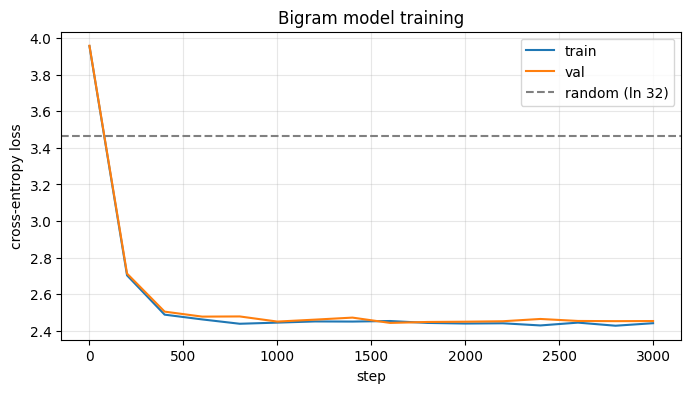

In [9]:
steps, trains, vals = zip(*history)
plt.figure(figsize=(8, 4))
plt.plot(steps, trains, label='train')
plt.plot(steps, vals,   label='val')
plt.axhline(math.log(VOCAB_SIZE), color='gray', linestyle='--', label=f'random (ln {VOCAB_SIZE})')
plt.xlabel('step')
plt.ylabel('cross-entropy loss')
plt.title('Bigram model training')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Cell 10 — Autoregressive generation

To generate text from a language model, we feed it a starting context, sample the next token from its predicted distribution, append it, and feed back. Repeat.

For bigram, only the *last* token matters (the model ignores everything else), so we could optimize. But we'll write the general version since later models will use the full context.

### Sampling vs argmax

We **sample** from the predicted distribution rather than greedy-argmax. Why? Argmax produces deterministic, repetitive output (`the the the the...`). Sampling produces diverse output that reflects the model's actual learned distribution. For a real chat model you'd add temperature/top-k/top-p; here we just sample from the raw softmax.

### What should we expect?

Bigram has no notion of *words*. It only knows "after `q`, `u` is likely" and "after space, capital letters and `t`/`a`/`s` are common" — that kind of one-step statistic. Expect output that:

- Has roughly correct character frequencies (lots of spaces, vowels, `e`s).
- Has plausible bigrams (`th`, `he`, `re`, `nd`).
- Has **no real words** — because making real words requires looking back further than one character.

This is the baseline. Anything notebook 03 onwards produces should look qualitatively better.


In [10]:
@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int = 300) -> str:
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)  # (1, T)
    for _ in range(max_new_tokens):
        logits = model(idx)              # (1, T, V)
        last   = logits[:, -1, :]        # (1, V) — only the final position matters for next-token
        probs  = F.softmax(last, dim=-1) # (1, V)
        nxt    = torch.multinomial(probs, num_samples=1)  # (1, 1)
        idx    = torch.cat([idx, nxt], dim=1)
    return decode(idx[0].tolist())

print(generate(model, prompt='\n', max_new_tokens=400))



llert y harverss in.
the, me p<unk><unk>fersouke, d rnsh!
b.
r okn, pur halay he, oveay ouk cane m ngre, inif wnte y seinyotire ce von<unk>unrothare meng ueerdet mpanofeiter wheshaserite wou f, wheacawhi fush, busondes,
can es d nt ican ssthengr at brovelende ar atrti is barucangs ugoulleramewatany be be cke!
gbrverimod thace gorre as whofathe:
be thitothin hesppris
ard<unk><unk>d ave te, wieed ar

rang e hnowhim pt 


## Post-mortem — what did we learn?

### Final loss interpretation

If your final val loss is around **2.5**, you can interpret it concretely: the model assigns the correct next character a probability of $e^{-2.5} ≈ 0.082$ on average. Random would be $\frac{1}{32} = 0.031$. So the model is roughly **2.6× better than random** at predicting the next character — purely from knowing the previous character.

### What bigram can't do (and why we need attention)

Bigram is structurally incapable of:

- **Closing brackets/quotes** — needs to remember opening.
- **Subject-verb agreement** — needs to remember subject.
- **Finishing a word someone started** — needs >1 char of context.
- **Any compositional pattern** at all.

The cure: a hidden state that **mixes information from earlier positions into the current one**. That's literally what attention is. We're about to build it by hand in notebook 02.

### The mental model going forward

Every notebook from here adds *one* concept to the bigram skeleton:

| Nb | Adds | Result |
|----|------|--------|
| 02 | Self-attention (by hand, no training) | Understand the mechanism |
| 03 | Train attention end-to-end | Beat bigram baseline |
| 04 | Multiple heads | Parallel attention patterns |
| 05 | LayerNorm + residuals | Trainability for deeper nets |
| 06 | Scale up (d=64) | Sanity check at "real" size |
| 07 | Shrink to d=8 + int8 | The 6502-bound model |

Onwards.
